In [68]:
import os
import re
import csv
import json
import subprocess

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from Bio import AlignIO

In [71]:
########## Generating the data frame and charts for NFIL3 conservation analysis ##########

In [73]:
##### For disorder with AIUPred: #####

In [75]:
#First obtain the AIUPRED v2 output JSON file, and put it in the right folder
with open("C:/Users/e216138h/Documents/Figures/Conservation_plddt_disorder/AIUPred/AIUPred_v2_mNFIL3.json", "r") as f:
    data_AIUPred = json.load(f)
    
aiupred = data_AIUPred["aiupred"]
aiupred_pct = [values * 100 for values in aiupred]

In [79]:
##### For the plDDT with AF3: #####

In [81]:
def find_files_AF3(directory, number_models=5):
    """
    Generates a JSON file path list for a specified number of models in a specified base path.
    
    Parameters:
    - directory (str): The default directory where the JSON files for the models are stored
    - number_models (int): number of structural models
    Returns:
    - json_files (list): List of full paths to the JSON files
    """

    # Run "select_plddt_CA.sh" must be in the same directory
    bash_directory = directory.replace("C:/", "/mnt/c/")
    subprocess.run(["bash", "./selec_plDDT_CA.sh", f"{bash_directory}"], capture_output=True, text=True)

    name = os.path.splitext(os.path.basename(directory))[0]
    json_files = [f"{directory}/{name}_model_{model}_result.json" for model in range(number_models)]
    return json_files
    

In [83]:
def merge_json_AF3(directory, input_files, key, output_file="merged_AF3.json"):
    """
    Merges multiple JSON files into a single file by calculating the average of the key values.
    
    Parameters:
     - directory (str): Path to the directory containing the JSON files
     - input_files (list): List of JSON files to merge
     - key (str): key to average
    Returns:
    - output_file (dict): Dictionary containing the averages
    """

    # Opening Files
    all_plddt = []
    for file in input_files:
        with open(file, "r") as f:
            data = json.load(f)      
        all_plddt.append(data[key])
    
    # Conversion to an array and calculation of the average by residue
    all_plddt = np.array(all_plddt)
    mean_plddt = np.mean(all_plddt, axis=0)
    
    # Use a reference file for the other indexes
    with open(input_files[0], "r") as f:
        ref_data = json.load(f)

    # Creating the dictionary
    output = {
        "nbr_res": ref_data["nbr_res"],
        "number_atoms": ref_data["number_atoms"],
        f"{key}_mean": mean_plddt.tolist()
    }
    
    # Output file path
    output_path = os.path.join(directory, output_file)

    # Saving data to a file
    with open(output_path, "w") as f:
        json.dump(output, f, indent=4)

    print(f"{key} averaged and saved in: {directory}/{output_file}")


In [86]:
### Main plDDT ###

base_path_plddt = "C:/Users/e216138h/Documents/Figures/Conservation_plddt_disorder/fold_mnfil3"
json_files_AF3 = find_files_AF3(base_path_plddt)

key = "plDDT"
merge_json_AF3(base_path_plddt, json_files_AF3, key)

with open(f"{base_path_plddt}/merged_AF3.json", "r") as f:
    data_merged = json.load(f)

plddt_af3_av = data_merged[f"{key}_mean"]

plDDT averaged and saved in: C:/Users/e216138h/Documents/Figures/Conservation_plddt_disorder/fold_mnfil3/merged_AF3.json


In [89]:
##### Alignment statistics (quality, conservation, and consensus) using Jalview: #####

In [90]:
def process_files(json_file_path, csv_file_path):
    """
    Extract the relevant values (quality, consensus and conservation) from .json and .csv files generated by Jalview.

    Parameters:
        json_file_path (str): .json file generated by Jalview
        csv_file_path (str): .csv file generated by Jalview
    Returns:
        updated_data (list): Output list containing the relevant values
    """
    
    with open(json_file_path, "r") as f:
        data_align = json.load(f)

    quality_values = []
    consensus_values = []
    conservation_values = []
    
    with open(csv_file_path, "r") as f:
        for line in f:
            if line.startswith("Quality,"):
                # Extract the values after "Quality,"
                quality_values = [float(value) for value in line.strip().split(",")[1:] if value.strip()]
            elif line.startswith("Consensus%,"):
                # Extract the values after "Consensus%,"
                # NOTE: Check if the column header is "Consensus%"; if not, add "%" to the first row labeled "Consensus" in the .csv file.
                consensus_values = [float(value) for value in line.strip().split(",")[1:] if value.strip()]
            elif line.startswith("Conservation,"):
                # Extract the values after "Conservation,"
                conservation_values = [float(value) for value in line.strip().split(",")[1:] if value.strip()]
    
    # Modifier les séquences et les valeurs dans "Quality"
    updated_data = {"name":[], "seq":[], "num":[], "longueur":[], "Conservation":[], "Quality":[], "Consensus%":[]}

    for entry in data_align["seqs"]:
        seq = entry["seq"]
        name = entry["name"]

        # Remove the gaps ("-") from seq and the corresponding values in "Quality"
        new_seq = ""
        new_quality = []
        new_consensus = []
        new_conservation = []
        num=[]

        tour = 0
        for i, char in enumerate(seq):      
            if char != "-":
                tour = tour + 1
                new_seq += char
                num.append(tour)
                new_quality.append(quality_values[i])
                new_consensus.append(consensus_values[i])
                new_conservation.append(conservation_values[i])


        # Add the length of the new sequence
        seq_length = len(new_seq)
        
        # Update the list of sequences
        updated_data["name"].append(name)
        updated_data["seq"].append(new_seq)
        updated_data["num"].append(num)
        updated_data["longueur"].append(seq_length)
        updated_data["Conservation"].append(new_conservation)
        updated_data["Quality"].append(new_quality)
        updated_data["Consensus%"].append(new_consensus)

    return updated_data
    

In [92]:
### Main Statistique ###
## NOTE: Obtain the "jalview_files_***.json" file using the "Files/Output to Textbox" tab in the Jalview tool.
## NOTE: Obtain the "jalview_annotations_***.csv" file using the "Files/Export Annotations..." tab in the Jalview tool.
# AND check whether to add the "%" to the first "Consensus" index in the .csv file

base_path_jalview = "C:/Users/e216138h/Documents/Figures/Conservation_plddt_disorder/Vertebre/Without_outliers/jalview_"
result = process_files(f"{base_path_jalview}files_without_outliers.json", f"{base_path_jalview}annotations_without_outliers.csv") # NOTE: Be careful with the files names...

with open(f"{base_path_jalview}output_conservation.json", "w") as output_file:
     json.dump(result, output_file, indent=4)

with open(f"{base_path_jalview}output_conservation.json", "r") as f:
    data_output = json.load(f)
    
quality = data_output["Quality"][0]
max_quality = max(quality)
quality_pct = [(i/max_quality)*100 for i in quality] # NOTE: Adjust the float based on the alignment => Look on Jalview if necessary
# 214.72736 for all species
# 208.96924 for all species without outliers (PM, OA, PS)
# 200.74225 for vertebrates
# 189.58107 for vertebrates without outliers (PM, OA, PS)

conservation = data_output["Conservation"][0]
conservation_pct = [(i/11)*100 for i in conservation]

consensus = data_output["Consensus%"][0]

In [95]:
##### Rapport omega (Conservation pressure: BEB prob w<1) #####

In [96]:
def get_aligned(aligned_fasta, reference_index=0):
    """
    Returns a dictionary that maps the positions of the residues in an aligned reference sequence to their corresponding positions in the unaligned reference sequence:
    aligned_position (1-based) -> ref_pos (1-based, without gaps)
    
    Parameters:
        aligned_fasta (str): Path to the aligned fasta file
        reference_index (int): Index of the reference sequence in the alignment (default: 0)
    Returns:
        mapping (dict): Dictionary mapping aligned positions to reference positions
    """
    
    alignment = AlignIO.read(aligned_fasta, "fasta")
    ref_seq = alignment[reference_index].seq

    ref_pos = 0
    aligned_index = 0
    mapping = {}

    for col_idx in range(alignment.get_alignment_length()):
        column = alignment[:, col_idx]

        if "-" in column:
            if ref_seq[col_idx] != "-":
                ref_pos += 1
            continue

        ref_pos += 1
        aligned_index += 1
        mapping[aligned_index] = ref_pos

    return mapping


In [97]:
def extract_beb_to_csv(aligned_fasta, rst_file, output_csv):
    """
    Extracts the BEB probabilities from the EasyCodeML rst file, and adds the position of the reference sequence.
    
    Parameters:
        aligned_fasta (str): Path to the aligned fasta file
        rst_file (str): Path to the EasyCodeML rst file
    Returns:
        CSV file
    """

    # Mapping aligned_position -> ref_pos
    aligned_ref_pos = get_aligned(aligned_fasta)

    # Reading the rst file
    with open(rst_file, "r", encoding="utf-8", errors="ignore") as f:
        lines = f.readlines()

    # Search for the BEB section
    start = None
    for i, line in enumerate(lines):
        if "Bayes Empirical Bayes (BEB)" in line:
            start = i
            break

    # Data extraction
    pattern = re.compile(
        r"""^\s*
        (\d+)                           # position
        \s+([A-Z\*-])                   # amino acid
        \s+((?:[\d\.]+\s+){10}[\d\.]+)  # 11 probalities
        \s+\(\s*(\d+)\s*\)              # most probable class
        \s+([\d\.]+)                    # mean_w
        \s*\+\-\s*                      # +-
        ([\d\.]+)                       # SD
        """,
        re.VERBOSE
    )

    data = []
    for line in lines[start:-1]:
        m = pattern.match(line)
        if m:
            aligned_pos = int(m.group(1))
            aa = m.group(2)

            best_class = int(m.group(4))
            mean_w = float(m.group(5))
            sd_w = float(m.group(6)) 
            
            probs = list(map(float, m.group(3).split()))
            pr_w_conservation = probs[0]
            best_pr = probs[best_class - 1]
            pr_w_selection = probs[10]
            
            ref_pos = aligned_ref_pos.get(aligned_pos, "")
             
            data.append([
                aligned_pos,
                ref_pos,
                aa,
                pr_w_conservation,
                best_pr,
                pr_w_selection,
                best_class,
                mean_w,
                sd_w
            ])

    # Writing the output CSV file
    with open(output_csv, "w", newline="", encoding="utf-8") as f:
        writer = csv.writer(f)
        writer.writerow([
            "site",
            "sequence position",
            "residue",
            "BEB prob classe 1",
            "Best BEB prob",
            "BEB prob classe 11",
            "Best class",
            "Postmean w",
            "SD w"
        ])
        writer.writerows(data)

    print(f"Generated CSV file in: {output_csv}")
    print(f"Number of sites extracted: {len(data)}")


In [99]:
### Main Omega ###

base_path_omega = "C:/Users/e216138h/Documents/Figures/Alignement_NFIL3/New/Vertebre/Without_PM_OA_PS"
fasta_file = f"{base_path_omega}/alignement_nfil3_prot_vertebre_without_PM_OA_PS.fasta"
rst_file = f"{base_path_omega}/SM_tree_prot/M8/rst"
csv_omega = f"{base_path_omega}/SM_tree_prot/M8/M8_site_probs.csv"

extract_beb_to_csv(fasta_file, rst_file, csv_omega)
df_omega = pd.read_csv(csv_omega)

Generated CSV file in: C:/Users/e216138h/Documents/Figures/Alignement_NFIL3/New/Vertebre/Without_PM_OA_PS/SM_tree_prot/M8/M8_site_probs.csv
Number of sites extracted: 280


In [102]:
##### Full DataFrame #####

In [103]:
# Search for the original sequence
base_path_seq = "C:/Users/e216138h/Documents/Figures/Conservation_plddt_disorder/fold_mnfil3"
seq = os.path.splitext(os.path.basename(base_path_seq))[0]
file_seq = base_path_seq+"/"+seq+"_job_request"

with open(f"{file_seq}.json", "r") as f:
    data_seq = json.load(f)

sequence = data_seq[0]["sequences"][0]["proteinChain"]["sequence"]

In [104]:
# Create a complete DataFrame containing all the positions of the residues
df_beb = pd.DataFrame({"position": range(1, len(sequence) + 1), "residue": list(sequence)})
res_pos = df_beb["position"]
res_name = df_beb["residue"]

# Set the columns to 0 
df_beb["BEB prob classe 1"] = 0
df_beb["Postmean w"] = 0
df_beb["SD w"] = 0

# Enter the BEB values for the corresponding positions and residues
for _, row in df_omega.iterrows():
    pos = row["sequence position"]
    res = row["residue"]
    prob = row["BEB prob classe 1"]
    mean = row["Postmean w"]
    sd = row["SD w"]
    if pos <= len(sequence) and df_beb.at[pos-1, "residue"] == res:
        df_beb.at[pos-1, "BEB prob classe 1"] = prob
        df_beb.at[pos-1, "Postmean w"] = mean
        df_beb.at[pos-1, "SD w"] = sd

BEB_classe1 = [i*100 for i in df_beb["BEB prob classe 1"]]
postmean_w = df_beb["Postmean w"].replace(0, np.nan)
# postmean_w = 1-df_beb["Postmean w"]
# postmean_w = [i*100 for i in Postmean_w].replace(0, np.nan)
sd_w = df_beb["SD w"].replace(0, np.nan)

C:\Users\e216138h\AppData\Local\Temp\ipykernel_26324\765370070.py:19: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.99994' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_beb.at[pos-1, "BEB prob classe 1"] = prob
C:\Users\e216138h\AppData\Local\Temp\ipykernel_26324\765370070.py:20: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.05' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_beb.at[pos-1, "Postmean w"] = mean
C:\Users\e216138h\AppData\Local\Temp\ipykernel_26324\765370070.py:21: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '0.001' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_beb.at[pos-1, "SD w"] = sd


In [105]:
df_all = []
df_all = pd.DataFrame({
    "Position": res_pos,
    "Name": res_name,
    "AIUPred": aiupred_pct,
    "pLDDT": plddt_af3_av,
    "Quality": quality_pct,
    "Conservation": conservation_pct,
    "Consensus": consensus,
    "BEB classe 1": BEB_classe1,
    "Postmean w": postmean_w,
    "SD w": sd_w
})

# Save
df_all.to_csv("data_all.csv", sep=";", index=False, encoding="utf-8")
df_all

,Position,Name,AIUPred,pLDDT,Quality,Conservation,Consensus,BEB classe 1,Postmean w,SD w
0,1,M,93.135887,33.18,34.672167,0.000000,71.641790,0.0,NaN,NaN
1,2,Q,94.035119,58.83,20.680179,0.000000,70.149254,0.0,NaN,NaN
2,3,L,94.601965,49.67,31.796843,0.000000,70.149254,0.0,NaN,NaN
3,4,R,95.063621,30.78,35.141755,27.272727,70.149254,0.0,NaN,NaN
4,5,K,95.235795,51.13,29.303424,9.090909,67.164180,0.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
457,458,A,75.980449,71.04,59.521138,18.181818,76.119400,0.0,NaN,NaN
458,459,S,79.460132,68.60,45.293578,0.000000,79.104480,0.0,NaN,NaN
459,460,D,81.738019,58.54,60.107080,27.272727,80.597015,0.0,NaN,NaN
460,461,S,81.089121,59.18,65.930016,27.272727,89.552240,0.0,NaN,NaN


In [108]:
##### Graphs #####
base_path_plot = "C:/Users/e216138h/Documents/Figures/Conservation_plddt_disorder/Vertebre/Without_outliers"

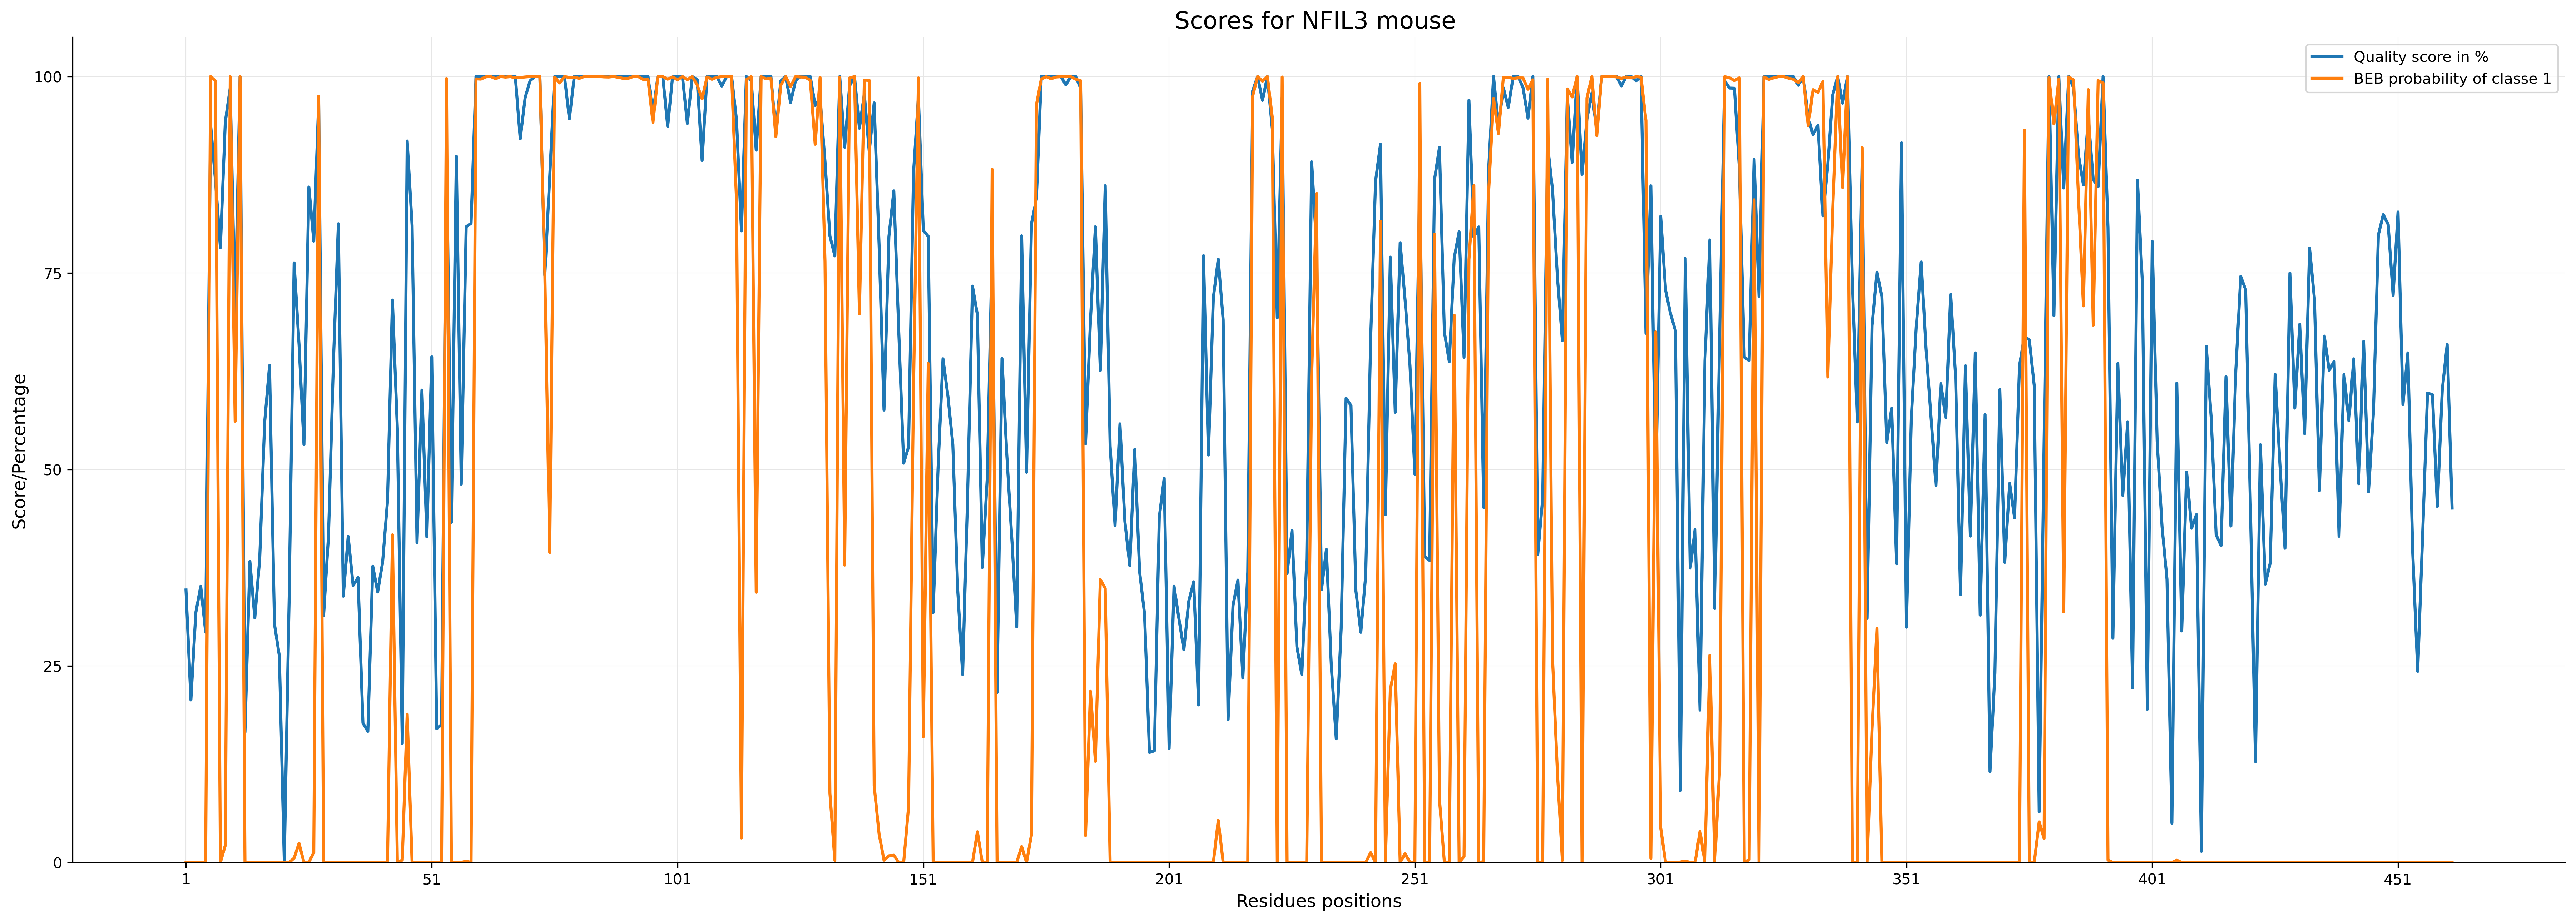

In [109]:
all_res = []
all_res.extend(df_all["Position"])
xmin, xmax = min(all_res), max(all_res)

plt.figure(figsize=(30, 10), dpi=300)
# c="#1f77b4", c="#d62728", c="#800080", c="#ff7f0e",

# plt.plot(df_all["Position"], df_all["AIUPred"], label="Disorder in %", linewidth=2)
# plt.plot(df_all["Position"], df_all["pLDDT"], label="pLDDT score", linewidth=2)
plt.plot(df_all["Position"], df_all["Quality"], label="Quality score in %", linewidth=2)
# plt.plot(df_all["Position"], df_all["Conservation"], label="Conservation score in %", linewidth=2)
# plt.plot(df_all["Position"], df_all["Consensus"], label="Consensus in %", linewidth=2)
plt.plot(df_all["Position"], df_all["BEB classe 1"], label="BEB probability of classe 1", linewidth=2)

# plt.title("Disordered residues for NFIL3 mouse", fontsize=16)
# plt.title("plDDT score for NFIL3 mouse", fontsize=16)
# plt.title("Alignement quality based on BLOSUM62 for NFIL3 mouse", fontsize=16)
# plt.title("Conservation score based on AMAS method for NFIL3 mouse", fontsize=16)
# plt.title("Consensus residues for all NFIL3 proteins", fontsize=16)
# plt.title("BEB probability of classe 1 for NFIL3 mouse", fontsize=16)

plt.title("Scores for NFIL3 mouse ", fontsize=16)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.ylim(0, 105)
plt.yticks(np.linspace(0, 100, 5))
plt.xticks(np.arange(xmin, xmax + 1, 50))
plt.xlabel("Residues positions", fontsize=12)
plt.ylabel("Score/Percentage", fontsize=12)

plt.legend()
# plt.savefig(f"{base_path_plot}/quality_BEB.png", dpi=300)
# plt.savefig(f"{base_path_plot}/quality_BEB.pdf", dpi=300)
plt.show()

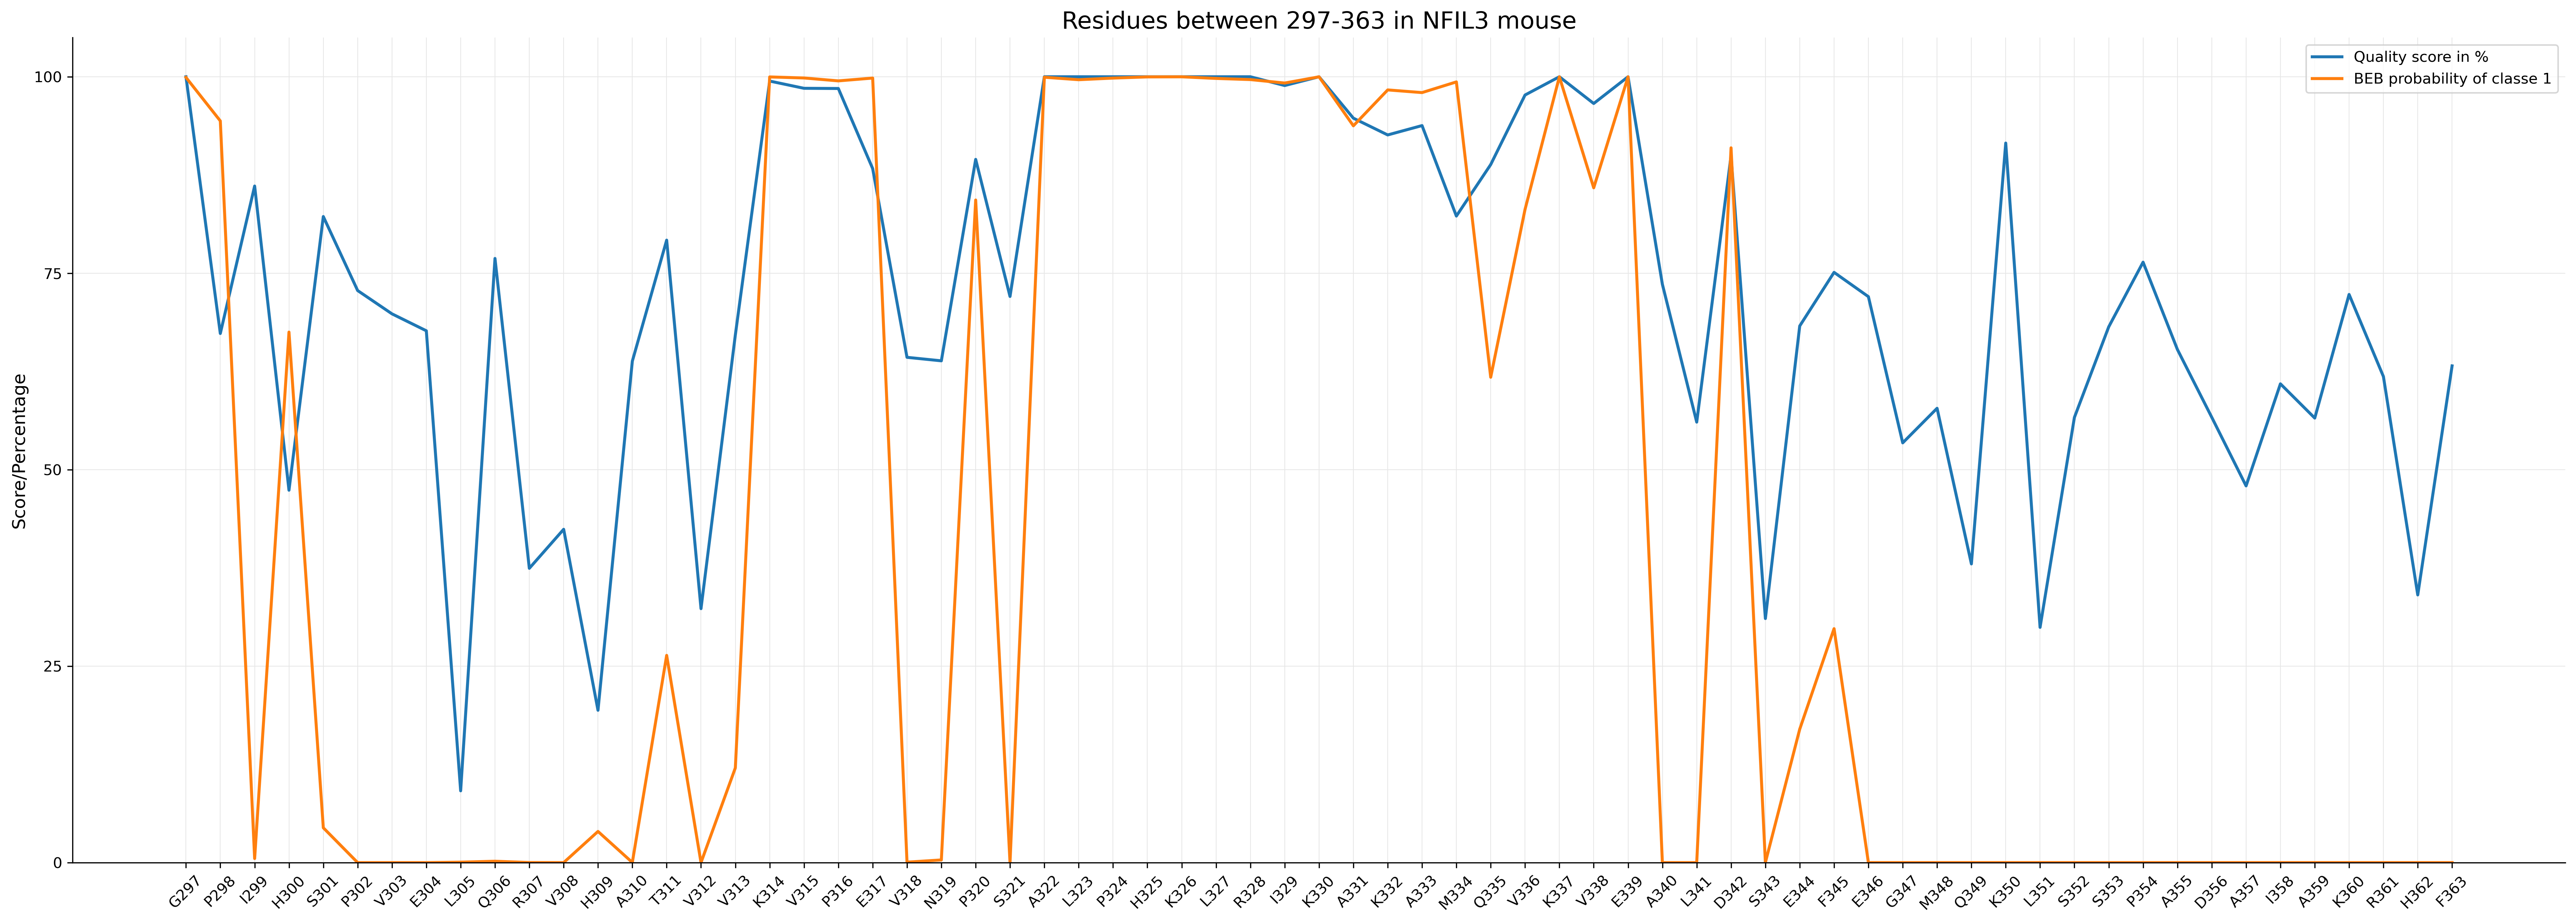

In [110]:
df_all["Name_Position"] = df_all["Name"] + df_all["Position"].astype(str)
seq_begin = 296
seq_end = 363

plt.figure(figsize=(30, 10), dpi=300)
# c="#1f77b4", c="#d62728", c="#800080", c="#ff7f0e",

# plt.plot(df_all["Name_Position"][seq_begin:seq_end], df_all["AIUPred"][seq_begin:seq_end], label="Disorder in %", linewidth=2)
# plt.plot(df_all["Name_Position"][seq_begin:seq_end], df_all["pLDDT"][seq_begin:seq_end], label="plDDT score", linewidth=2)
plt.plot(df_all["Name_Position"][seq_begin:seq_end], df_all["Quality"][seq_begin:seq_end], label="Quality score in %", linewidth=2)
# plt.plot(df_all["Name_Position"][seq_begin:seq_end], df_all["Conservation"][seq_begin:seq_end], label="Conservation score in %", linewidth=2)
# plt.plot(df_all["Name_Position"][seq_begin:seq_end], df_all["Consensus"][seq_begin:seq_end], label="Consensus in %", linewidth=2)
plt.plot(df_all["Name_Position"][seq_begin:seq_end], df_all["BEB classe 1"][seq_begin:seq_end], label="BEB probability of classe 1", linewidth=2)

# plt.title(f"Disordered for residues between {seq_begin+1}-{seq_end} in NFIL3 mouse", fontsize=16)
# plt.title(f"plDDT score for residues between {seq_begin+1}-{seq_end} in NFIL3 mouse", fontsize=16)
# plt.title(f"Alignement quality based on BLOSUM62 for residues between {seq_begin+1}-{seq_end} in NFIL3 mouse", fontsize=16)
# plt.title(f"Conservation score based on AMAS method for residues between {seq_begin+1}-{seq_end} in NFIL3 mouse", fontsize=16)
# plt.title(f"Consensus residues for residues between {seq_begin+1}-{seq_end} in all NFIL3 proteins", fontsize=16)
# plt.title(f"BEB probability of classe 1 for residues between {seq_begin+1}-{seq_end} in NFIL3 mouse", fontsize=16)

plt.title(f"Residues between {seq_begin+1}-{seq_end} in NFIL3 mouse", fontsize=16)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.ylim(0, 105)
plt.yticks(np.linspace(0, 100, 5))
plt.xticks(rotation=45)
plt.ylabel("Score/Percentage", fontsize=12)

plt.legend()
# plt.savefig(f"{base_path_plot}/quality_BEB_MRD.png", dpi=300)
# plt.savefig(f"{base_path_plot}/quality_BEB_MRD.pdf", dpi=300)
plt.show()

In [112]:
# Plot Postmean w

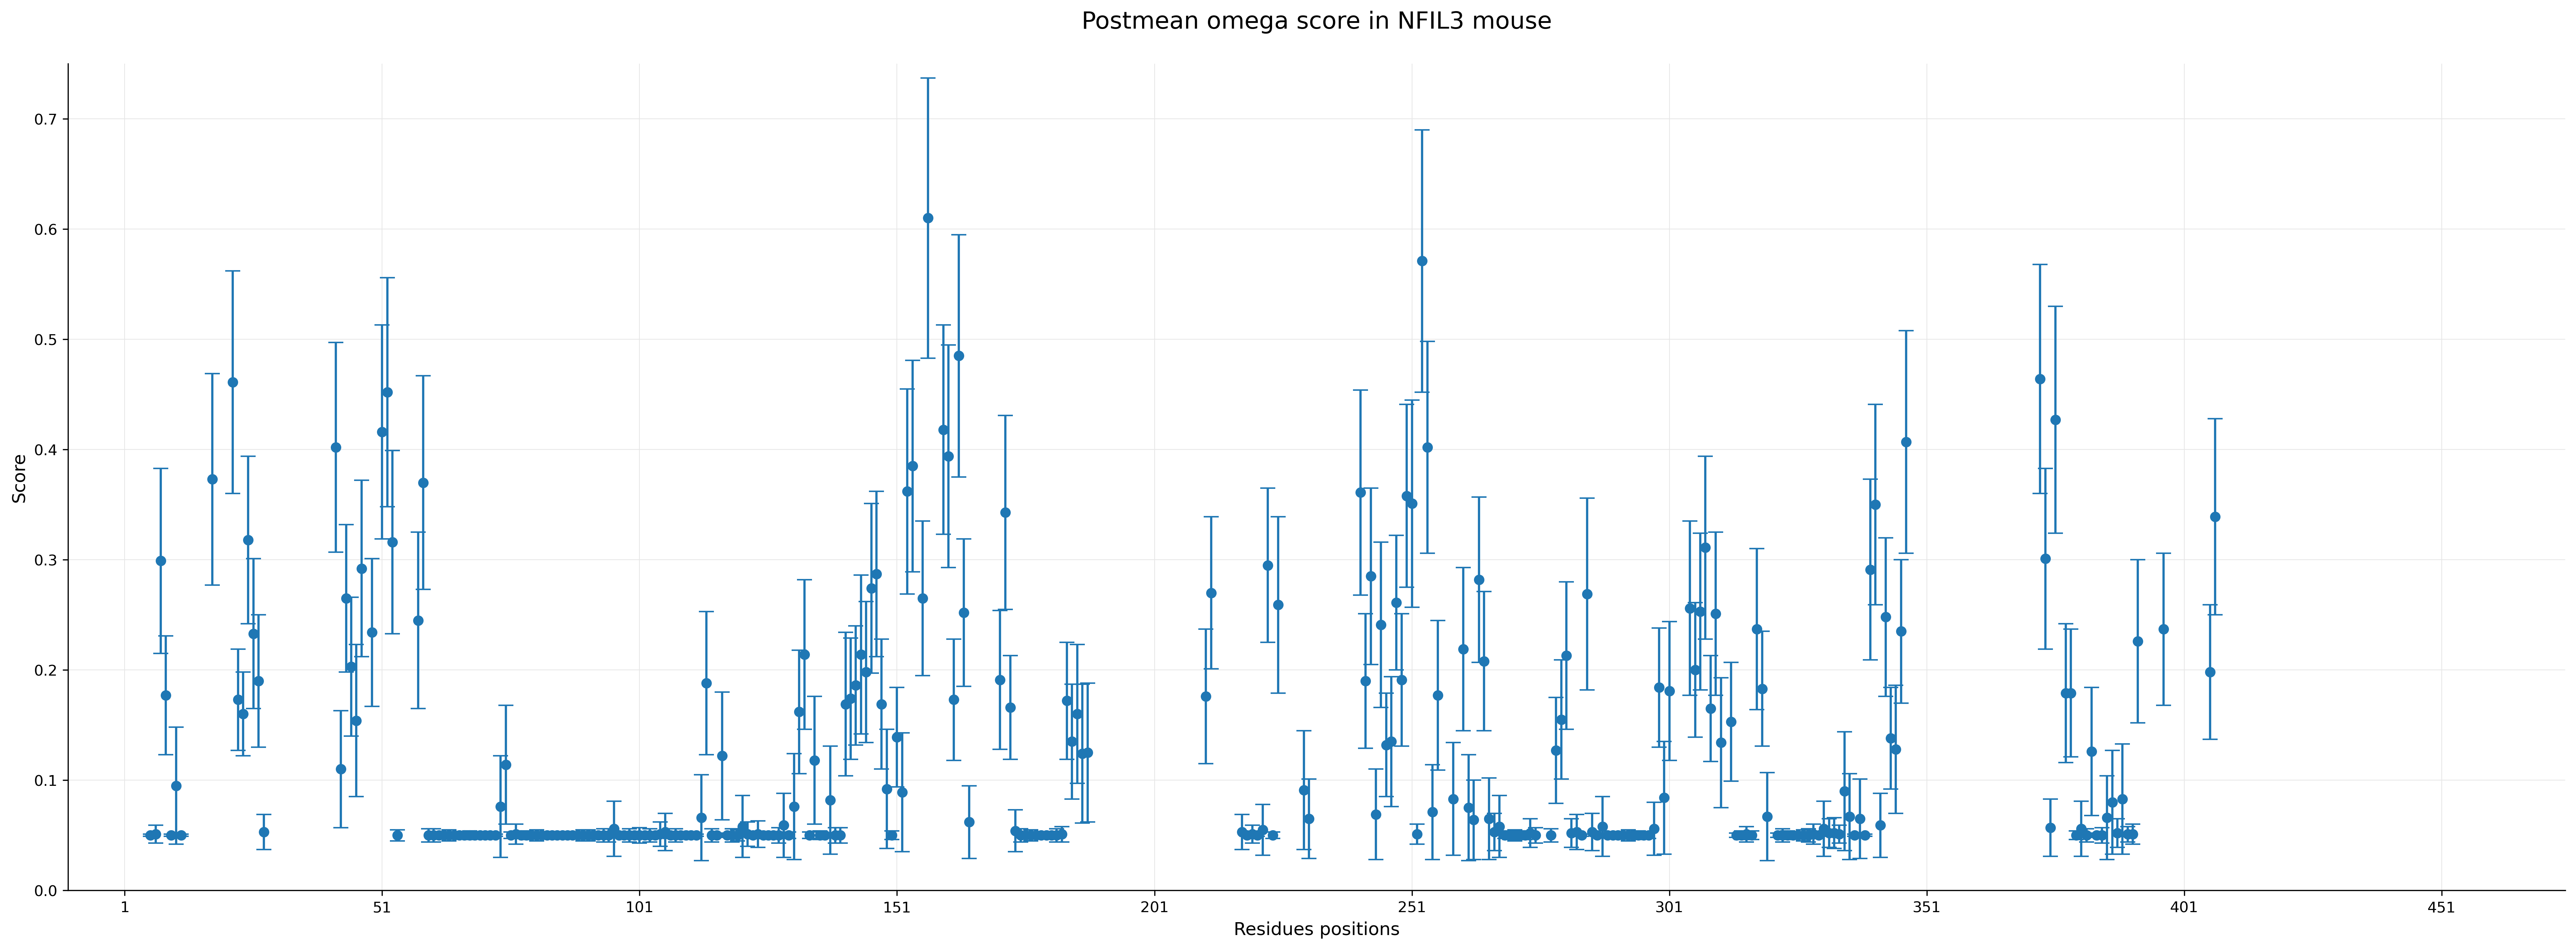

In [113]:
plt.figure(figsize=(30, 10), dpi=300)
plt.errorbar(df_all["Position"], df_all["Postmean w"], yerr=df_all["SD w"], fmt="o", capsize=5)
plt.title("Postmean omega score in NFIL3 mouse\n", fontsize=16)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xticks(np.arange(xmin, xmax + 1, 50))
plt.xlim(-10, 475)
plt.ylim(0, 0.75)
plt.xlabel("Residues positions", fontsize=12)
plt.ylabel("Score", fontsize=12)
# plt.savefig(f"{base_path_plot}/postmean_w.png", dpi=300)
# plt.savefig(f"{base_path_plot}/postmean_w.pdf", dpi=300)
plt.show()

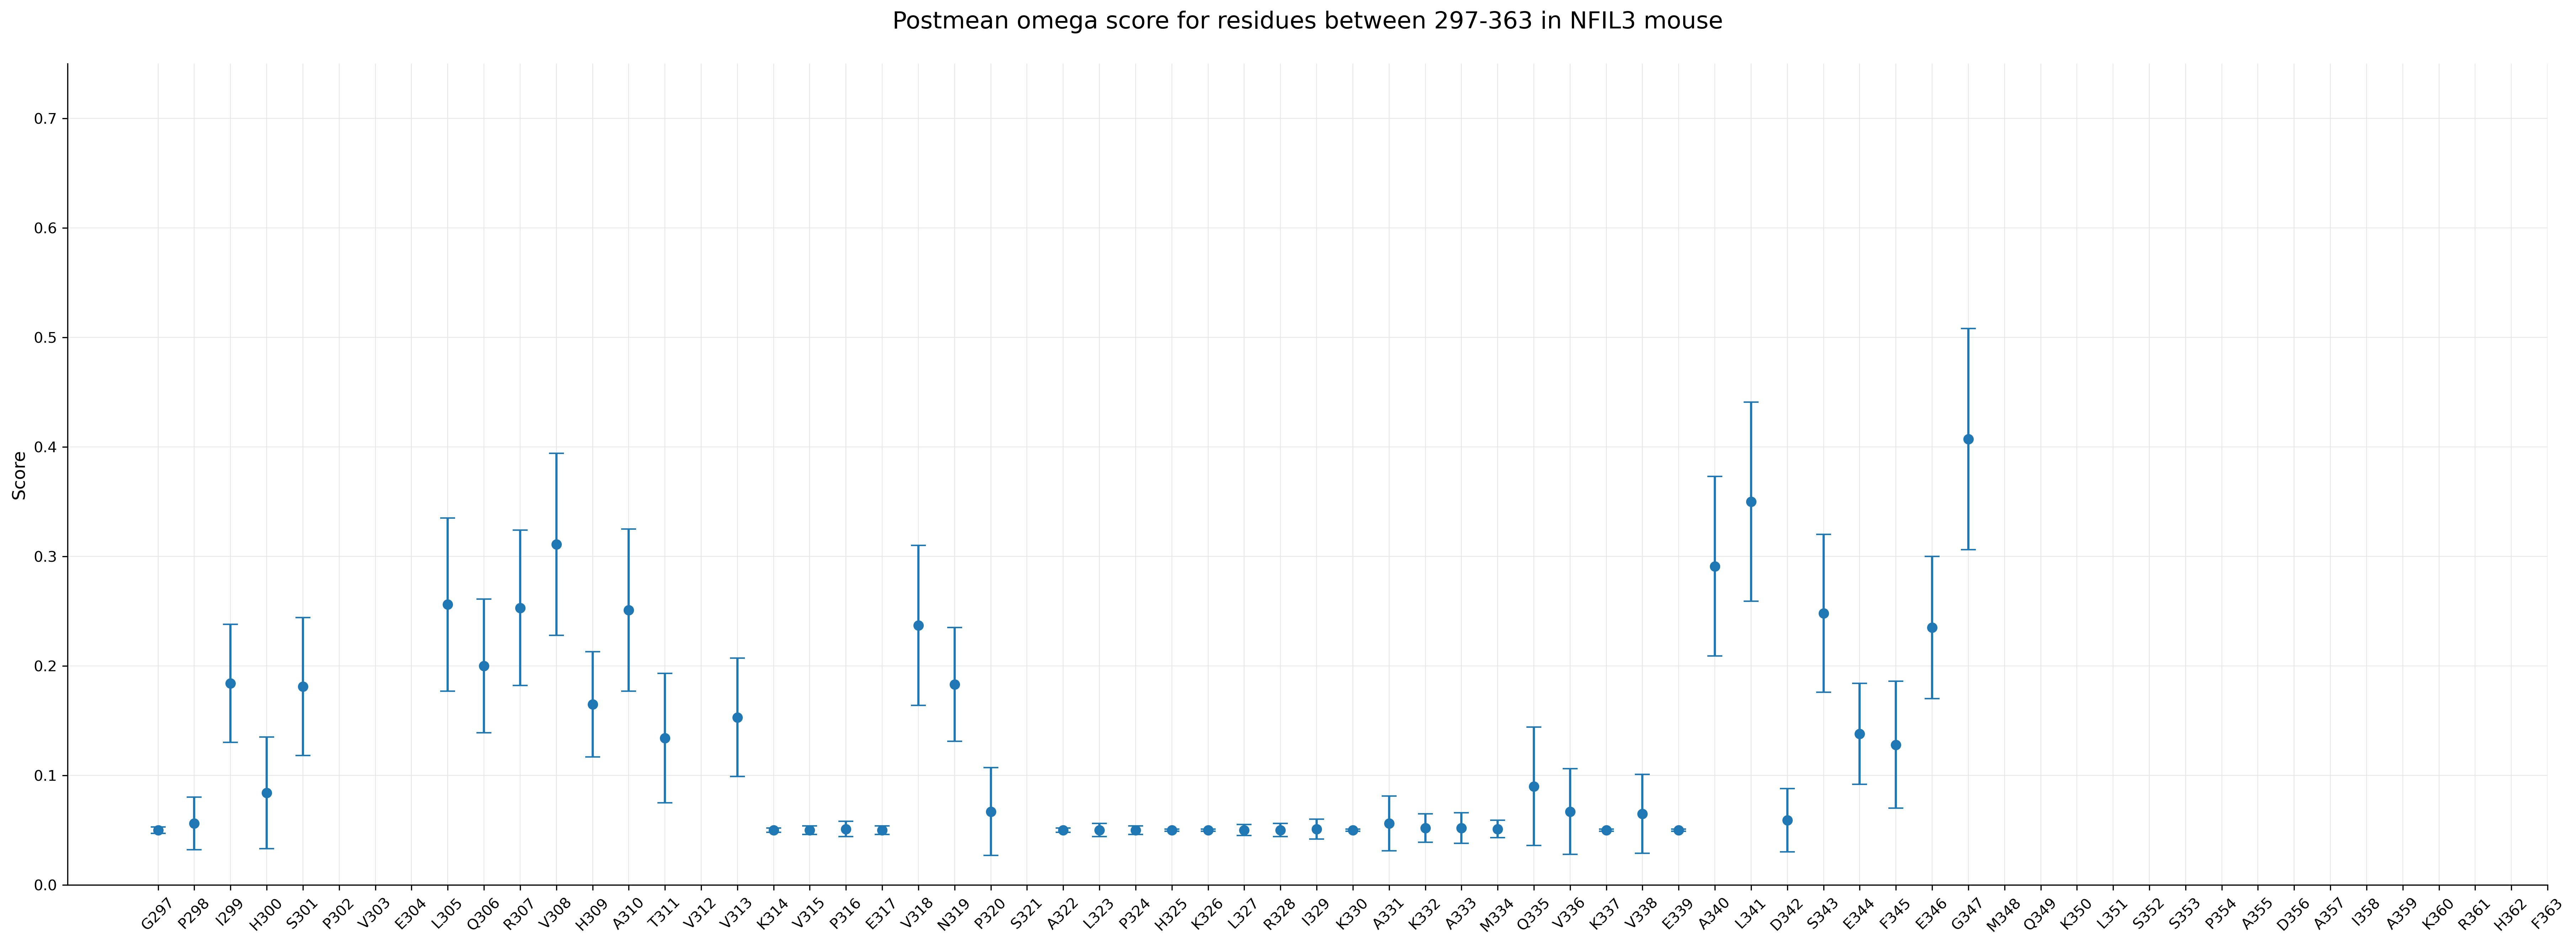

In [114]:
x = range(len(df_all["Position"][seq_begin:seq_end]))
plt.figure(figsize=(30, 10), dpi=300)
plt.errorbar(x, df_all["Postmean w"][seq_begin:seq_end], yerr=df_all["SD w"][seq_begin:seq_end], fmt="o", capsize=5)
plt.title(f"Postmean omega score for residues between {seq_begin+1}-{seq_end} in NFIL3 mouse\n", fontsize=16)
plt.grid(color="0.9", linestyle="-", linewidth=0.5)
plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.xticks(x, df_all["Name_Position"][seq_begin:seq_end])
plt.xticks(rotation=45)
plt.ylim(0, 0.75)
plt.ylabel("Score", fontsize=12)
# plt.savefig(f"{base_path_plot}/postmean_w_MRD.png", dpi=300)
# plt.savefig(f"{base_path_plot}/postmean_w_MRD.pdf", dpi=300)
plt.show()